Steel demand

In [197]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy.optimize import curve_fit
import pandas_datareader.wb as wb
import statsmodels.api as sm
from scipy import stats

Load data

In [190]:
# Load data

def load_files(filename):
    base_path = Path.cwd().parent
    historic_folder = base_path / "data" / "raw" / "Steel"
    
    file_path = historic_folder / filename
    df = pd.read_excel(file_path)
    
    return df

steel_file = "steel_demand.xlsx"

steel_data = load_files(steel_file)

base_path = Path.cwd().parent
future_GDP_path = base_path / "data" / "raw" / "future_GDP.csv"
future_GDP = pd.read_csv(future_GDP_path)

Look at data

In [191]:
# Look at the data
display(steel_data)

,Year,Population,Steel,GDP
0,1850,NaN,0.0,2.140000e+12
1,1851,NaN,NaN,NaN
2,1852,NaN,NaN,NaN
3,1853,NaN,NaN,NaN
4,1854,NaN,NaN,NaN
...,...,...,...,...
246,2096,NaN,NaN,NaN
247,2097,NaN,NaN,NaN
248,2098,NaN,NaN,NaN
249,2099,NaN,NaN,NaN


Clean data

In [308]:
# New dataframe with relevant columns for steel production from 1850 to 1949
steel_1850 = steel_data[steel_data["Year"] < 1950][["Year", "Steel", "GDP", "Population"]].copy()

# New dataframe for steel production from 1950 to 2020
steel_1950 = steel_data[(steel_data["Year"] >= 1950) & (steel_data["Year"] < 2021)][["Year", "Steel", "GDP", "Population"]].copy()

# Add GDP and population data w/ indicator code
gdp_indicator = "NY.GDP.MKTP.CD" # GDP (current US$) - https://data.worldbank.org/indicator/NY.GDP.MKTP.CD
population_indicator = "SP.POP.TOTL" # Population, total - https://data.worldbank.org/indicator/SP.POP.TOTL

# Range from 1950 where data is missing and end at the last year in steel_1950
start_year = steel_1950["Year"].min()
end_year = steel_1950["Year"].max()

# Download GDP and population data for the world aggregate (WLD) from the World Bank and add to steel_1950
gdp_data = wb.download(
    indicator=gdp_indicator,
    country="WLD",            # WLD = world aggregate
    start=start_year,
    end=end_year
)

population_data = wb.download(
    indicator=population_indicator,
    country="WLD",
    start=start_year,
    end=end_year
)

# Rename for clarity
gdp_data = gdp_data.rename(columns={gdp_indicator: "GDP"})
gdp_data = gdp_data.reset_index()
#population_data = population_data.rename(columns={population_indicator: "Population"})
#population_data = population_data.reset_index()

# Ensure year columns are integers
steel_1950["Year"] = steel_1950["Year"].astype(int)
gdp_data["year"] = gdp_data["year"].astype(int)
#population_data["year"] = population_data["year"].astype(int)

# Merge GDP into steel_1950 by matching years
steel_1950 = steel_1950.merge(
    gdp_data[["year", "GDP"]],
    left_on="Year",       # your steel dataframe column
    right_on="year",      # GDP dataframe column
    how="left"
)

# Merge steel_1850 and steel_1950 for a complete dataset from 1850 to 2020
#steel_historic = steel_1950[["Year", "Steel", "GDP"]].copy()
steel_historic = pd.concat([steel_1850, steel_1950], ignore_index=True)

# Combine columns GDP and GDP_y into one column
steel_historic["GDP_current_USD"] = steel_historic["GDP"].combine_first(steel_historic["GDP_y"])

# Drop the original GDP columns, population columns, and any other unnecessary columns
steel_historic = steel_historic.drop(columns=["GDP", "GDP_x", "GDP_y", "Population", "year"])

# Look at the merged data
print(steel_historic)

# Download GDP data for 2021 to 2024
gdp_data_2021_2024 = wb.download(
    indicator=gdp_indicator,
    country="WLD",            # WLD = world aggregate
    start=2021,
    end=2024
)

# Make list of GDP from 2021 to 2024 and reverse them to match the order of years in steel_2021_2024
gdp_2021_2024 = gdp_data_2021_2024[gdp_indicator].tolist()
gdp_2021_2024.reverse()

# Add data for steel production from 2021 to 2024
steel_2021_2024 = pd.DataFrame({
    "Year": [2021, 2022, 2023, 2024],
    "Steel": [1963, 1889, 1904, 1885], # in Mt, from World Steel Association
    "GDP_current_USD": gdp_2021_2024
})

print(steel_2021_2024)

# Combine steel_historic and steel_2021_2024 for a complete dataset from 1850 to 2024
steel_historic = pd.concat([steel_historic, steel_2021_2024], ignore_index=True)

# Look at the complete dataset
print(steel_historic)

c:\Users\ovid\AppData\Local\miniconda3\envs\masterthesis\Lib\site-packages\pandas_datareader\wb.py:592: UserWarning: Non-standard ISO country codes: WLD
  warnings.warn(
C:\Users\ovid\AppData\Local\Temp\ipykernel_37724\2207968835.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gdp_data = wb.download(
c:\Users\ovid\AppData\Local\miniconda3\envs\masterthesis\Lib\site-packages\pandas_datareader\wb.py:592: UserWarning: Non-standard ISO country codes: WLD
  warnings.warn(
C:\Users\ovid\AppData\Local\Temp\ipykernel_37724\2207968835.py:23: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  population_data = wb.download(
c:\Users\ovid\AppData\Local\miniconda3\envs\masterthesis\Lib\site-packages\pandas_datareader\wb.py:592: UserWarning: Non-standard ISO country cod

     Year   Steel  GDP_current_USD
0    1850     0.0     2.140000e+12
1    1851     NaN              NaN
2    1852     NaN              NaN
3    1853     NaN              NaN
4    1854     NaN              NaN
..    ...     ...              ...
166  2016  1634.0     7.683168e+13
167  2017  1738.0     8.183910e+13
168  2018  1831.0     8.705096e+13
169  2019  1879.0     8.848326e+13
170  2020  1883.0     8.591276e+13

[171 rows x 3 columns]
   Year  Steel  GDP_current_USD
0  2021   1963     9.814048e+13
1  2022   1889     1.022515e+14
2  2023   1904     1.067416e+14
3  2024   1885     1.109827e+14
     Year   Steel  GDP_current_USD
0    1850     0.0     2.140000e+12
1    1851     NaN              NaN
2    1852     NaN              NaN
3    1853     NaN              NaN
4    1854     NaN              NaN
..    ...     ...              ...
170  2020  1883.0     8.591276e+13
171  2021  1963.0     9.814048e+13
172  2022  1889.0     1.022515e+14
173  2023  1904.0     1.067416e+14
174  2024  

C:\Users\ovid\AppData\Local\Temp\ipykernel_37724\2207968835.py:63: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gdp_data_2021_2024 = wb.download(


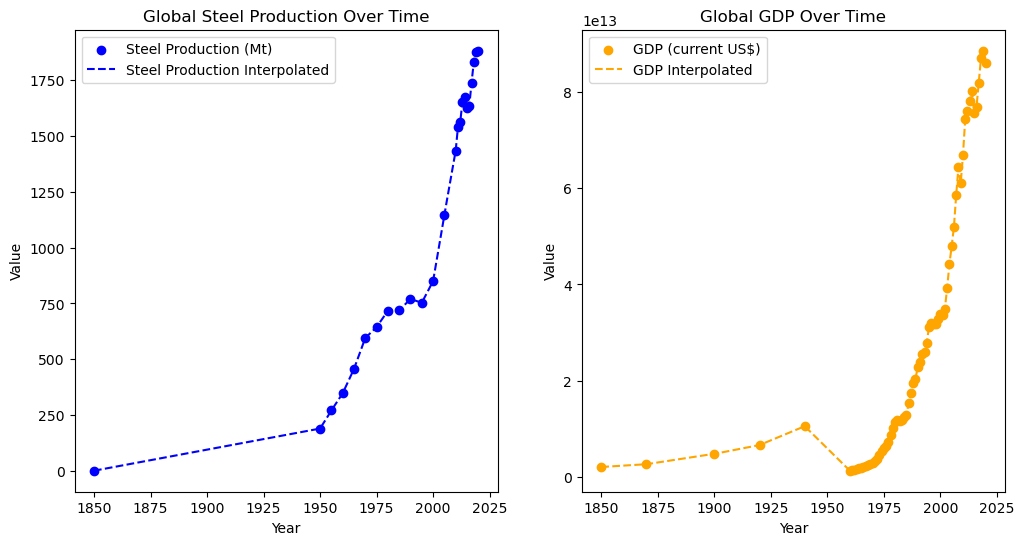

In [193]:
# Interpolate steel and GDP for missing years
steel_historic["Steel Interpolated"] = steel_historic["Steel"].interpolate(method="linear")
steel_historic["GDP Interpolated"] = steel_historic["GDP_current_USD"].interpolate(method="linear")

# Plot steel production and GDP over time in two separate subplots, with interpolated values included
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(steel_historic["Year"], steel_historic["Steel"], label="Steel Production (Mt)", color="blue")
plt.plot(steel_historic["Year"], steel_historic["Steel Interpolated"], label="Steel Production Interpolated", color="blue", linestyle="--")
plt.title("Global Steel Production Over Time")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(steel_historic["Year"], steel_historic["GDP_current_USD"], label="GDP (current US$)", color="orange")
plt.plot(steel_historic["Year"], steel_historic["GDP Interpolated"], label="GDP Interpolated", color="orange", linestyle="--")
plt.title("Global GDP Over Time")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.show()

In [341]:
# Log transform data to check correlation of growth rates from 1995 to 2024
steel_historic_1995 = steel_historic[steel_historic["Year"] >= 1995].copy()

# Remove Nan values before log transformation
steel_historic_1995 = steel_historic_1995.dropna(subset=['Steel', 'GDP_current_USD'])

# method 1: Calculate log-differences (log growth rates) for steel and GDP
steel_historic_1995['steel_log_growth'] = np.log(steel_historic_1995['Steel']).diff()
steel_historic_1995['gdp_log_growth'] = np.log(steel_historic_1995['GDP_current_USD']).diff()

# Remove NaN values resulting from the diff() operation
steel_historic_1995 = steel_historic_1995.dropna(subset=['steel_log_growth', 'gdp_log_growth'])

# Calculate correlation between log growth rates
log_growth_corr = steel_historic_1995['steel_log_growth'].corr(steel_historic_1995['gdp_log_growth'])

# Method 2: pct_change (for comparison)
pct_corr = steel_historic_1995['Steel'].pct_change().corr(steel_historic_1995['GDP_current_USD'].pct_change())

# Compare results from both methods
print(f"Log-diff correlation: {log_growth_corr:.4f}")
print(f"Pct change correlation: {pct_corr:.4f}")

# Calculate Pearson correlation coefficient and p-value for log growth rates
r, p_value = stats.pearsonr(steel_historic_1995['steel_log_growth'], steel_historic_1995['gdp_log_growth'])
print(f"Correlation: {r:.4f}")
print(f"P-value: {p_value:.10f}")
print(f"N observations: {len(steel_historic_1995)}")

# Perform leave-one-out analysis to check robustness of correlation
for i in range(len(steel_historic_1995)):
    mask = [j for j in range(len(steel_historic_1995)) if j != i]
    r_loo, _ = stats.pearsonr(steel_historic_1995.iloc[mask, 0], steel_historic_1995.iloc[mask, 1])
    year = steel_historic_1995.index[i]
    print(f"Drop {year}: r = {r_loo:.4f}")

# Average GDP and steel production over time
avg_gdp = steel_historic_1995["GDP_current_USD"].mean() * 1e6 # Convert from billion USD to USD
avg_steel = steel_historic_1995["Steel"].mean() * 1e6 # Convert from Mt to tons

# Find the constant average GDP per ton of steel produced
constant_avg = avg_gdp / avg_steel 
print(constant_avg)

Log-diff correlation: 0.9215
Pct change correlation: 0.9458
Correlation: 0.9215
P-value: 0.0000001501
N observations: 17
Drop 150: r = 0.9519
Drop 155: r = 0.9585
Drop 160: r = 0.9643
Drop 161: r = 0.9675
Drop 162: r = 0.9665
Drop 163: r = 0.9697
Drop 164: r = 0.9680
Drop 165: r = 0.9655
Drop 166: r = 0.9665
Drop 167: r = 0.9653
Drop 168: r = 0.9660
Drop 169: r = 0.9657
Drop 170: r = 0.9642
Drop 171: r = 0.9642
Drop 172: r = 0.9655
Drop 173: r = 0.9673
Drop 174: r = 0.9748
48787313032.43837


In [342]:
# Future dataframe
GDP_future = future_GDP[
    (future_GDP["region"] == "World") &
    (future_GDP["variable"] == "GDP|PPP") &
    (future_GDP["unit"] == "billion USD_2017/yr") &
    (future_GDP["scenario"].isin(["SSP1", "SSP2", "SSP3", "SSP5"]))
]

# Keep relevant columns and rename
GDP_future = GDP_future[["scenario"] + [col for col in GDP_future.columns if col.startswith("20")]]

# Only columns with years 2025, 2030, 2035, 2040, 2045, 2050
GDP_future = GDP_future[["scenario", "2025", "2030", "2035", "2040", "2045", "2050"]]

GDP_long = GDP_future.melt(
    id_vars="scenario",
    var_name="Year",
    value_name="GDP"
)

GDP_future = GDP_long.pivot(
    index="Year",
    columns="scenario",
    values="GDP"
).reset_index()

# Make sure 'Year' is numeric
GDP_future["Year"] = GDP_future["Year"].astype(int)

# Set Year as index
GDP_future = GDP_future.set_index("Year")

# Transform GDP from billion USD_2017/yr to current USD
GDP_future = GDP_future * 1e9

# Reindex to full yearly range
GDP_future = GDP_future.reindex(range(2021, 2051))

# Add steel_2021_2024 GDP values to the start of GDP_future
for year in range(2021, 2025):
    if year in steel_2021_2024["Year"].values:
        gdp_value = steel_2021_2024.loc[steel_2021_2024["Year"] == year, "GDP_current_USD"].values[0]
        GDP_future.loc[year] = [gdp_value] * len(GDP_future.columns)

display(GDP_future)

scenario,SSP1,SSP2,SSP3,SSP5
Year,,,,
2021,9.814048e+13,9.814048e+13,9.814048e+13,9.814048e+13
2022,1.022515e+14,1.022515e+14,1.022515e+14,1.022515e+14
2023,1.067416e+14,1.067416e+14,1.067416e+14,1.067416e+14
2024,1.109827e+14,1.109827e+14,1.109827e+14,1.109827e+14
2025,1.517441e+14,1.517442e+14,1.517426e+14,1.517459e+14
2026,NaN,NaN,NaN,NaN
2027,NaN,NaN,NaN,NaN
2028,NaN,NaN,NaN,NaN
2029,NaN,NaN,NaN,NaN


In [350]:
# GDP grows exponentially, interpolate in log space to get more realistic growth rates for missing years
def interpolate_ssp_gdp(df, ssps=['SSP1', 'SSP2', 'SSP3', 'SSP5']):
    """
    Log-linear interpolation of GDP projections for each SSP scenario.
    Assumes df has a datetime/integer index with 5-year intervals.
    """
    # Reindex to yearly frequency
    full_index = range(df.index.min(), df.index.max() + 1)
    df_interp = df.reindex(full_index)
    
    for ssp in ssps:
        if ssp not in df.columns:
            print(f"Warning: {ssp} not found in dataframe, skipping")
            continue
        
        log_col = f'log_{ssp}'
        df_interp[log_col] = np.log(df_interp[ssp])
        df_interp[log_col] = df_interp[log_col].interpolate(method='linear')
        df_interp[f'{ssp}_interpolated'] = np.exp(df_interp[log_col])
        df_interp.drop(columns=[log_col], inplace=True)  # clean up log columns
    
    return df_interp

# Usage
GDP_interp = interpolate_ssp_gdp(GDP_future)

# Check result
#print(GDP_interp[[f'{ssp}_interpolated' for ssp in ['SSP1','SSP2','SSP3','SSP5']]].head(20))

# Use constant_avg to estimate steel production from GDP projections for each scenario
steel_future = GDP_interp.copy()

# Drop the original GDP columns to keep only interpolated values for clarity
steel_future = steel_future[[col for col in steel_future.columns if col.endswith("_interpolated")]]

for scenario in GDP_interp.columns:
    steel_future[scenario] = GDP_interp[scenario] / constant_avg

display(steel_future)

scenario,SSP1_interpolated,SSP2_interpolated,SSP3_interpolated,SSP5_interpolated,SSP1,SSP2,SSP3,SSP5
Year,,,,,,,,
2021,2011.598286,2011.598286,2011.598286,2011.598286,2011.598286,2011.598286,2011.598286,2011.598286
2022,2095.863010,2095.863010,2095.863010,2095.863010,2095.863010,2095.863010,2095.863010,2095.863010
2023,2187.897656,2187.897656,2187.897656,2187.897656,2187.897656,2187.897656,2187.897656,2187.897656
2024,2274.826267,2274.826267,2274.826267,2274.826267,2274.826267,2274.826267,2274.826267,2274.826267
2025,3110.318738,3110.320809,3110.289023,3110.355522,3110.318738,3110.320809,3110.289023,3110.355522
2026,3208.085821,3206.804310,3205.298363,3209.900179,NaN,NaN,NaN,NaN
2027,3308.926031,3306.280771,3303.209932,3312.630691,NaN,NaN,NaN,NaN
2028,3412.935965,3408.843035,3404.112385,3418.649017,NaN,NaN,NaN,NaN
2029,3520.215258,3514.586824,3508.097084,3528.060383,NaN,NaN,NaN,NaN


In [351]:
# Make new empty dataframe with one column per scenario from 1995 to 2050
steel_scenarios = pd.DataFrame({
    "Year": range(1995, 2051),
    "SSP1": np.nan,
    "SSP2": np.nan,
    "SSP3": np.nan,
    "SSP5": np.nan
})

# Combine historical data with future projections for each scenario and fill in the dataframe
for scenario in ["SSP1_interpolated", "SSP2_interpolated", "SSP3_interpolated", "SSP5_interpolated"]:
    # Fill historical data from 1995 to 2024
    for year in range(1995, 2025):
        if year in steel_historic["Year"].values:
            steel_scenarios.loc[steel_scenarios["Year"] == year, scenario] = steel_historic.loc[steel_historic["Year"] == year, "Steel"].values[0]
    
    # Fill future projections
    for year in range(2025, 2051):
        if year in steel_future.index:
            steel_scenarios.loc[steel_scenarios["Year"] == year, scenario] = steel_future.loc[year, scenario]

display(steel_scenarios)

,Year,SSP1,SSP2,SSP3,SSP5,SSP1_interpolated,SSP2_interpolated,SSP3_interpolated,SSP5_interpolated
0,1995,NaN,NaN,NaN,NaN,753.000000,753.000000,753.000000,753.000000
1,1996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2000,NaN,NaN,NaN,NaN,850.000000,850.000000,850.000000,850.000000
6,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


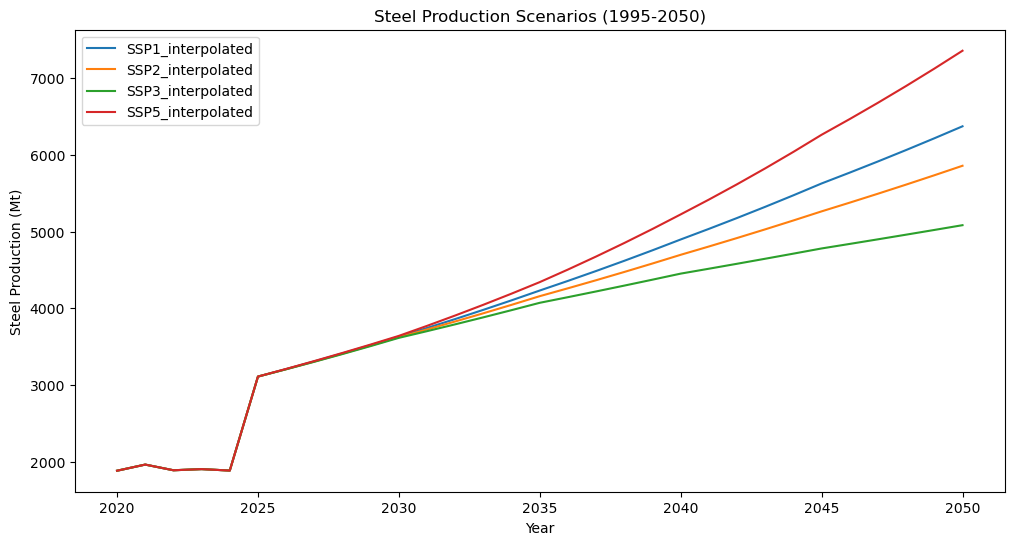

In [352]:
# Display the scenarios from 1995 to 2050
plt.figure(figsize=(12, 6))
for scenario in ["SSP1_interpolated", "SSP2_interpolated", "SSP3_interpolated", "SSP5_interpolated"]:
    plt.plot(steel_scenarios[steel_scenarios["Year"] >= 2020]["Year"], steel_scenarios[steel_scenarios["Year"] >= 2020][scenario], label=scenario)
#plt.scatter(steel_historic["Year"], steel_historic["Steel"], label="Historical Steel Production", color="black", linestyle="--")
plt.title("Steel Production Scenarios (1995-2050)")
plt.xlabel("Year")
plt.ylabel("Steel Production (Mt)")
plt.legend()
plt.show()